In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.size"] = 10
plt.rcParams["figure.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# ==========================================
# 1. LOAD DATASETS & PREPROCESS
# ==========================================
PATH_LR_SUMMARY = r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\data\regression_results_lr_backbone+ml\run_20260806_161515\results\summary_mean_std.csv"
PATH_LR_PREDS = r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\data\regression_results_lr_backbone+ml\run_20260806_161515\results\fold_predictions.csv"

PATH_SR_SUMMARY = r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\data\regression_results_sr\results\summary_mean_std.csv"
PATH_SR_PREDS = r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\data\regression_results_sr\results\fold_predictions.csv"

# Load Summaries (Keep spectral_only)
df_sum_lr = pd.read_csv(PATH_LR_SUMMARY)
df_sum_sr = pd.read_csv(PATH_SR_SUMMARY)
df_sum_lr["dataset"] = "LR"
df_sum_sr["dataset"] = "SR"

# Load Predictions (Keep spectral_only)
df_pred_lr = pd.read_csv(PATH_LR_PREDS)
df_pred_sr = pd.read_csv(PATH_SR_PREDS)
df_pred_lr["dataset"] = "LR"
df_pred_sr["dataset"] = "SR"

# Combined DataFrames for Part 3
df_sum_combined = pd.concat([df_sum_lr, df_sum_sr], ignore_index=True)
df_pred_combined = pd.concat([df_pred_lr, df_pred_sr], ignore_index=True)

print(f"Loaded LR Summaries ({len(df_sum_lr)}) | Loaded SR Summaries ({len(df_sum_sr)})")

Loaded LR Summaries (203) | Loaded SR Summaries (217)



=================== TOP REGRESSION CONFIGURATIONS (LR) ===================


,feature_set,selection_label,regressor,r2_mean,rmse_mean,mae_mean
0,spectral_only,mi_top_50,bayesian_ridge,0.590625,23.560692,18.667779
1,spectral_only,mi_top_50,ridge,0.589397,23.600486,18.616563
35,spectral_only,mi_top_49,hist_gradient_boosting,0.552047,27.528825,22.501778
2,spectral_only,mi_top_40,bayesian_ridge,0.538457,25.531923,20.188489
3,spectral_only,mi_top_40,ridge,0.537534,25.553968,20.250480



================ TOP CLASSIFICATION CONFIGURATIONS (LR) ================


,feature_set,selection_label,regressor,severity_f1_macro_mean,severity_accuracy_mean,severity_balanced_accuracy_mean
13,swin_plus_spectral,mi_top_30,hist_gradient_boosting,0.633958,0.640205,0.642940
15,spectral_only,mi_top_30,ridge,0.613406,0.622705,0.625742
60,spectral_only,mi_top_49,random_forest,0.612703,0.625000,0.680808
82,spectral_only,mi_top_49,extra_trees,0.605705,0.625000,0.684848
23,spectral_only,mi_top_30,bayesian_ridge,0.600700,0.609665,0.614092


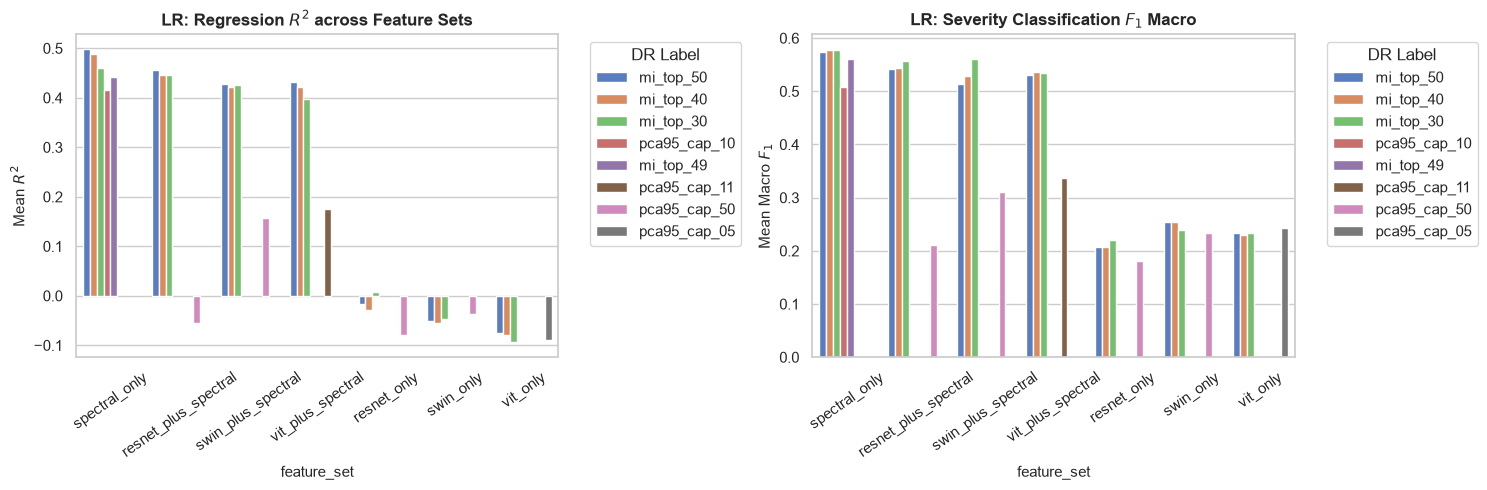

In [16]:
# Helper function for leaderboard extraction
def get_leaderboards(df_summary, label=""):
    print(f"\n=================== TOP REGRESSION CONFIGURATIONS ({label}) ===================")
    reg_cols = ["feature_set", "selection_label", "regressor", "r2_mean", "rmse_mean", "mae_mean"]
    top_reg = df_summary.sort_values(by="r2_mean", ascending=False)[reg_cols].head(5)
    display(top_reg)

    print(f"\n================ TOP CLASSIFICATION CONFIGURATIONS ({label}) ================")
    clf_cols = ["feature_set", "selection_label", "regressor", "severity_f1_macro_mean", "severity_accuracy_mean", "severity_balanced_accuracy_mean"]
    top_clf = df_summary.sort_values(by="severity_f1_macro_mean", ascending=False)[clf_cols].head(5)
    display(top_clf)

# 1. LR Leaderboards
get_leaderboards(df_sum_lr, label="LR")

# 2. Performance by Feature Set (including spectral_only)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=df_sum_lr,
    x="feature_set",
    y="r2_mean",
    hue="selection_label",
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("LR: Regression $R^2$ across Feature Sets", fontweight="bold")
axes[0].set_ylabel("Mean $R^2$")
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title="DR Label", bbox_to_anchor=(1.05, 1), loc='upper left')

sns.barplot(
    data=df_sum_lr,
    x="feature_set",
    y="severity_f1_macro_mean",
    hue="selection_label",
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("LR: Severity Classification $F_1$ Macro", fontweight="bold")
axes[1].set_ylabel("Mean Macro $F_1$")
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(title="DR Label", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


=================== TOP REGRESSION CONFIGURATIONS (SR) ===================


,feature_set,selection_label,regressor,r2_mean,rmse_mean,mae_mean
0,spectral_only,mi_top_50,bayesian_ridge,0.590625,23.560692,18.667779
1,spectral_only,mi_top_50,ridge,0.589397,23.600486,18.616563
24,spectral_only,mi_top_49,hist_gradient_boosting,0.552047,27.528825,22.501778
2,spectral_only,mi_top_40,bayesian_ridge,0.538457,25.531923,20.188489
3,spectral_only,mi_top_40,ridge,0.537534,25.553968,20.250480



================ TOP CLASSIFICATION CONFIGURATIONS (SR) ================


,feature_set,selection_label,regressor,severity_f1_macro_mean,severity_accuracy_mean,severity_balanced_accuracy_mean
6,spectral_only,mi_top_30,ridge,0.613406,0.622705,0.625742
38,spectral_only,mi_top_49,random_forest,0.612703,0.625000,0.680808
48,swin_plus_spectral,mi_top_30,hist_gradient_boosting,0.608196,0.620261,0.631905
82,spectral_only,mi_top_49,extra_trees,0.605705,0.625000,0.684848
8,spectral_only,mi_top_30,bayesian_ridge,0.600700,0.609665,0.614092


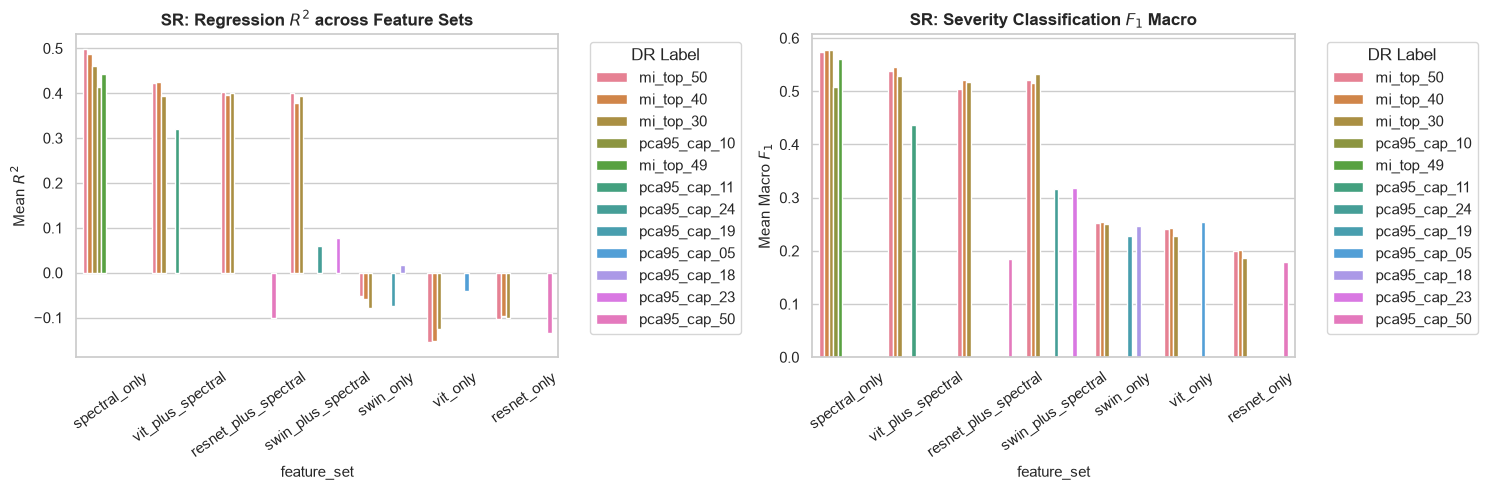

In [17]:
# 1. SR Leaderboards
get_leaderboards(df_sum_sr, label="SR")

# 2. Performance by Feature Set (including spectral_only)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=df_sum_sr,
    x="feature_set",
    y="r2_mean",
    hue="selection_label",
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("SR: Regression $R^2$ across Feature Sets", fontweight="bold")
axes[0].set_ylabel("Mean $R^2$")
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title="DR Label", bbox_to_anchor=(1.05, 1), loc='upper left')

sns.barplot(
    data=df_sum_sr,
    x="feature_set",
    y="severity_f1_macro_mean",
    hue="selection_label",
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("SR: Severity Classification $F_1$ Macro", fontweight="bold")
axes[1].set_ylabel("Mean Macro $F_1$")
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(title="DR Label", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

=================== TOP 5 LARGEST GAINS FROM SUPER RESOLUTION (SR) ===================


,feature_set,selection_label,regressor,r2_mean_LR,r2_mean_SR,delta_R2,rmse_mean_LR,rmse_mean_SR,delta_RMSE
104,vit_plus_spectral,pca95_cap_11,bayesian_ridge,0.106417,0.337704,0.231287,35.585318,30.443802,-5.141516
103,vit_plus_spectral,pca95_cap_11,ridge,0.107260,0.334958,0.227698,35.563090,30.505535,-5.057555
100,vit_plus_spectral,pca95_cap_11,svr,0.147825,0.361536,0.213711,34.741658,29.888822,-4.852835
188,vit_only,pca95_cap_05,hist_gradient_boosting,-0.322430,-0.172761,0.149668,42.802326,40.269774,-2.532552
98,vit_plus_spectral,pca95_cap_11,extra_trees,0.214305,0.361329,0.147024,33.361130,29.945893,-3.415238
177,swin_only,mi_top_40,ridge,-0.113306,-0.004321,0.108985,39.553292,37.531193,-2.022098
174,swin_only,mi_top_50,ridge,-0.106565,-0.002398,0.104167,39.475058,37.492475,-1.982583
151,vit_only,pca95_cap_05,random_forest,-0.052745,0.033774,0.086518,38.414350,36.865075,-1.549275
182,vit_only,pca95_cap_05,xgboost,-0.151621,-0.072277,0.079344,39.987140,38.718099,-1.269041
97,vit_plus_spectral,pca95_cap_11,random_forest,0.214788,0.293414,0.078625,33.257715,31.384203,-1.873513


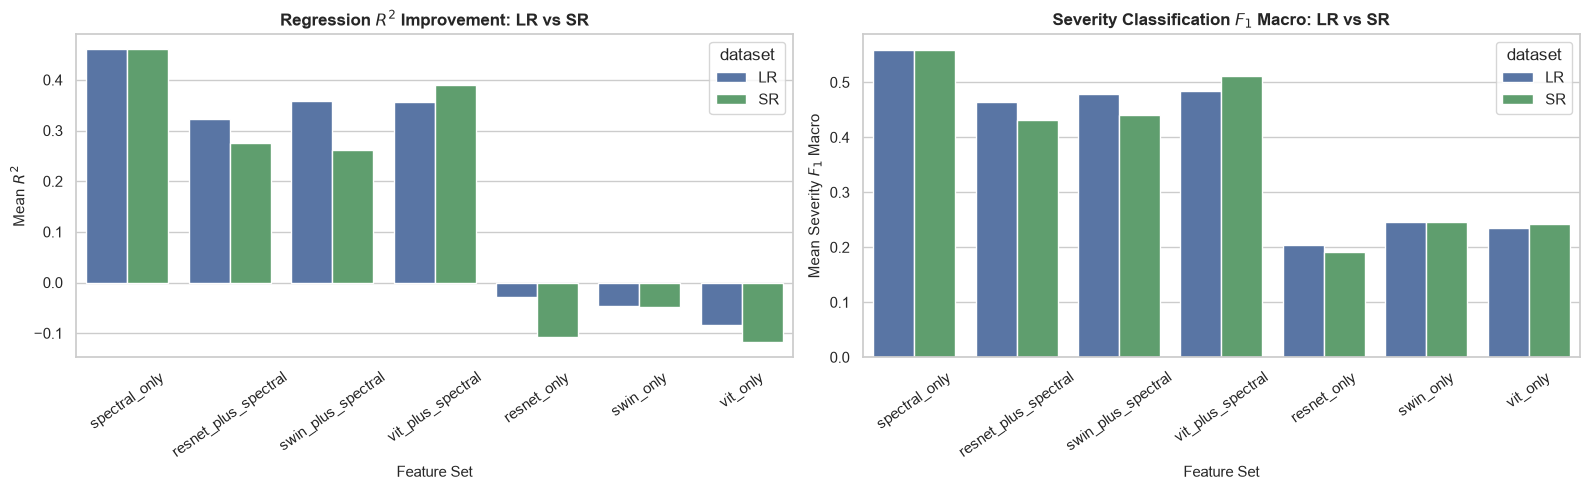

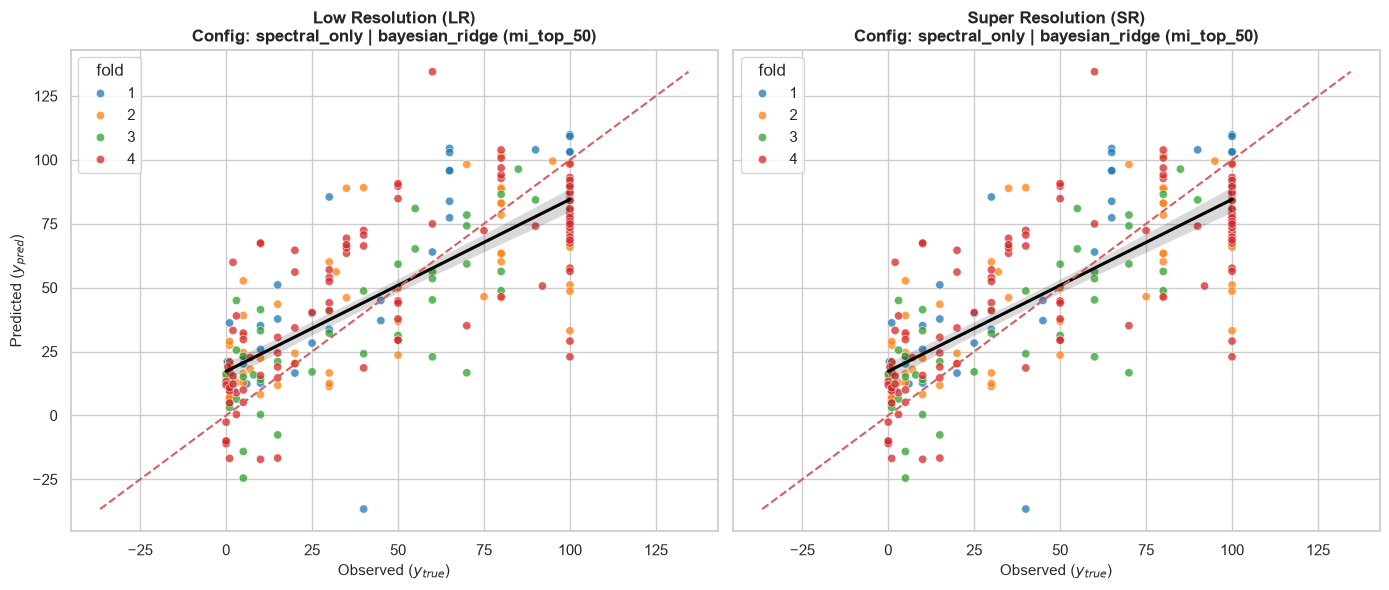

In [20]:
# ==========================================
# 3.1 EXACT PAIRWISE DELTA ANALYSIS (SR - LR)
# ==========================================
merge_keys = ["feature_set", "selection_label", "regressor"]
df_merged = pd.merge(
    df_sum_lr,
    df_sum_sr,
    on=merge_keys,
    suffixes=("_LR", "_SR")
)

df_merged["delta_R2"] = df_merged["r2_mean_SR"] - df_merged["r2_mean_LR"]
df_merged["delta_RMSE"] = df_merged["rmse_mean_SR"] - df_merged["rmse_mean_LR"]
df_merged["delta_Macro_F1"] = df_merged["severity_f1_macro_mean_SR"] - df_merged["severity_f1_macro_mean_LR"]

print("=================== TOP 5 LARGEST GAINS FROM SUPER RESOLUTION (SR) ===================")
display(df_merged.sort_values(by="delta_R2", ascending=False)[
    merge_keys + ["r2_mean_LR", "r2_mean_SR", "delta_R2", "rmse_mean_LR", "rmse_mean_SR", "delta_RMSE"]
].head(10))

# ==========================================
# 3.2 GROUPED COMPARISON PLOTS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall Feature Set Comparison (Includes spectral_only)
sns.barplot(
    data=df_sum_combined,
    x="feature_set",
    y="r2_mean",
    hue="dataset",
    palette={"LR": "#4C72B0", "SR": "#55A868"},
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("Regression $R^2$ Improvement: LR vs SR", fontweight="bold")
axes[0].set_ylabel("Mean $R^2$")
axes[0].set_xlabel("Feature Set")
axes[0].tick_params(axis='x', rotation=35)

sns.barplot(
    data=df_sum_combined,
    x="feature_set",
    y="severity_f1_macro_mean",
    hue="dataset",
    palette={"LR": "#4C72B0", "SR": "#55A868"},
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Severity Classification $F_1$ Macro: LR vs SR", fontweight="bold")
axes[1].set_ylabel("Mean Severity $F_1$ Macro")
axes[1].set_xlabel("Feature Set")
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

# ==========================================
# 3.3 OBSERVED VS PREDICTED (TOP OVERALL MODEL: LR vs SR)
# ==========================================
best_overall_config = df_sum_sr.sort_values(by="r2_mean", ascending=False).iloc[0]

f_set = best_overall_config["feature_set"]
s_label = best_overall_config["selection_label"]
reg = best_overall_config["regressor"]

preds_lr_top = df_pred_lr[(df_pred_lr["feature_set"] == f_set) & (df_pred_lr["selection_label"] == s_label) & (df_pred_lr["regressor"] == reg)]
preds_sr_top = df_pred_sr[(df_pred_sr["feature_set"] == f_set) & (df_pred_sr["selection_label"] == s_label) & (df_pred_sr["regressor"] == reg)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, data_preds, stage_name in zip(axes, [preds_lr_top, preds_sr_top], ["Low Resolution (LR)", "Super Resolution (SR)"]):
    if data_preds.empty:
        ax.set_title(f"{stage_name}: No Predictions Available")
        continue

    sns.scatterplot(
        data=data_preds,
        x="y_true",
        y="y_pred",
        hue="fold",
        palette="tab10",
        alpha=0.75,
        ax=ax
    )
    sns.regplot(data=data_preds, x="y_true", y="y_pred", scatter=False, color="black", ax=ax)
    
    min_v = min(data_preds["y_true"].min(), data_preds["y_pred"].min())
    max_v = max(data_preds["y_true"].max(), data_preds["y_pred"].max())
    ax.plot([min_v, max_v], [min_v, max_v], 'r--', label="1:1 Reference")
    
    ax.set_title(f"{stage_name}\nConfig: {f_set} | {reg} ({s_label})", fontweight="bold")
    ax.set_xlabel("Observed ($y_{true}$)")
    ax.set_ylabel("Predicted ($y_{pred}$)")

plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure global styles are set
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 11

# ==========================================
# 0. PREPARE DATASET CATEGORIZATIONS
# ==========================================
# Add feature classification tags to combined summaries and predictions
def categorize_feature_set(f_set):
    if f_set == "spectral_only":
        return "Spectral Only"
    elif any(b in f_set for b in ["swin", "resnet", "vit"]):
        return "Deep Backbone"
    else:
        return "Combined / Other"

df_sum_combined["category"] = df_sum_combined["feature_set"].apply(categorize_feature_set)
df_pred_combined["category"] = df_pred_combined["feature_set"].apply(categorize_feature_set)

# Filter out non-relevant categories if any exist
df_core_sum = df_sum_combined[df_sum_combined["category"].isin(["Spectral Only", "Deep Backbone"])].copy()
df_core_pred = df_pred_combined[df_pred_combined["category"].isin(["Spectral Only", "Deep Backbone"])].copy()

print("Data categorizations complete:")
print(df_core_sum.groupby(["dataset", "category", "feature_set"]).size())

Data categorizations complete:
dataset  category       feature_set         
LR       Deep Backbone  resnet_only             28
                        resnet_plus_spectral    28
                        swin_only               28
                        swin_plus_spectral      28
                        vit_only                28
                        vit_plus_spectral       28
         Spectral Only  spectral_only           35
SR       Deep Backbone  resnet_only             28
                        resnet_plus_spectral    28
                        swin_only               35
                        swin_plus_spectral      35
                        vit_only                28
                        vit_plus_spectral       28
         Spectral Only  spectral_only           35
dtype: int64


In [22]:
# ==========================================
# 1. SUMMARY STATISTICS: SPECTRAL VS DEEP BACKBONES
# ==========================================
print("\n" + "="*80)
print("  TABLE 1: AVERAGE & MAX PERFORMANCE BY CATEGORY (LR vs SR)")
print("="*80)

table_summary = df_core_sum.groupby(["dataset", "category", "feature_set"]).agg(
    r2_mean=("r2_mean", "mean"),
    r2_max=("r2_mean", "max"),
    rmse_mean=("rmse_mean", "mean"),
    rmse_min=("rmse_mean", "min"),
    f1_macro_mean=("severity_f1_macro_mean", "mean"),
    f1_macro_max=("severity_f1_macro_mean", "max")
).reset_index()

display(table_summary.round(4))


  TABLE 1: AVERAGE & MAX PERFORMANCE BY CATEGORY (LR vs SR)


,dataset,category,feature_set,r2_mean,r2_max,rmse_mean,rmse_min,f1_macro_mean,f1_macro_max
0,LR,Deep Backbone,resnet_only,-0.0291,0.0481,38.1432,36.7343,0.2038,0.2913
1,LR,Deep Backbone,resnet_plus_spectral,0.3231,0.5268,30.5012,25.9144,0.4636,0.5992
2,LR,Deep Backbone,swin_only,-0.0472,0.0192,38.4203,37.2349,0.2455,0.3183
3,LR,Deep Backbone,swin_plus_spectral,0.3582,0.5108,29.8793,26.2333,0.4788,0.6340
4,LR,Deep Backbone,vit_only,-0.0845,-0.0213,39.0307,37.8956,0.2346,0.3111
5,LR,Deep Backbone,vit_plus_spectral,0.3566,0.4784,29.8910,26.9364,0.4843,0.5794
6,LR,Spectral Only,spectral_only,0.4609,0.5906,27.8669,23.5607,0.5592,0.6134
7,SR,Deep Backbone,resnet_only,-0.1082,-0.0345,39.6451,38.3088,0.1913,0.2559
8,SR,Deep Backbone,resnet_plus_spectral,0.2746,0.4712,31.6441,27.3164,0.4318,0.5709
9,SR,Deep Backbone,swin_only,-0.0490,0.0725,38.2457,35.1099,0.2465,0.2998


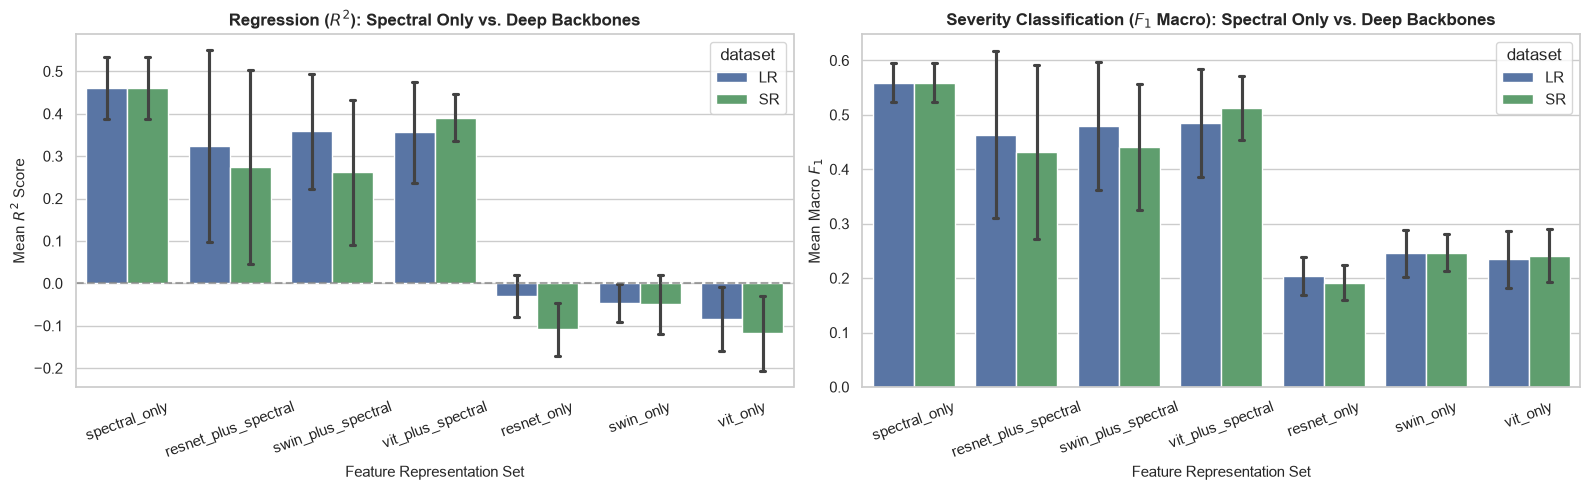

In [23]:
# ==========================================
# 2. GROUPED COMPARISON PLOTS (LR vs SR)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 2A: Regression R2
sns.barplot(
    data=df_core_sum,
    x="feature_set",
    y="r2_mean",
    hue="dataset",
    palette={"LR": "#4C72B0", "SR": "#55A868"},
    errorbar="sd",
    capsize=0.1,
    ax=axes[0]
)
axes[0].set_title("Regression ($R^2$): Spectral Only vs. Deep Backbones", fontweight="bold")
axes[0].set_ylabel("Mean $R^2$ Score")
axes[0].set_xlabel("Feature Representation Set")
axes[0].tick_params(axis='x', rotation=20)
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.7)

# Plot 2B: Severity Classification F1 Macro
sns.barplot(
    data=df_core_sum,
    x="feature_set",
    y="severity_f1_macro_mean",
    hue="dataset",
    palette={"LR": "#4C72B0", "SR": "#55A868"},
    errorbar="sd",
    capsize=0.1,
    ax=axes[1]
)
axes[1].set_title("Severity Classification ($F_1$ Macro): Spectral Only vs. Deep Backbones", fontweight="bold")
axes[1].set_ylabel("Mean Macro $F_1$")
axes[1].set_xlabel("Feature Representation Set")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

<>:27: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:28: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:27: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:28: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_8724\1933057792.py:27: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.title("Distribution of $R^2$ Gain ($\Delta R^2 = SR - LR$) across Feature Sets", fontweight="bold")
C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_8724\19330

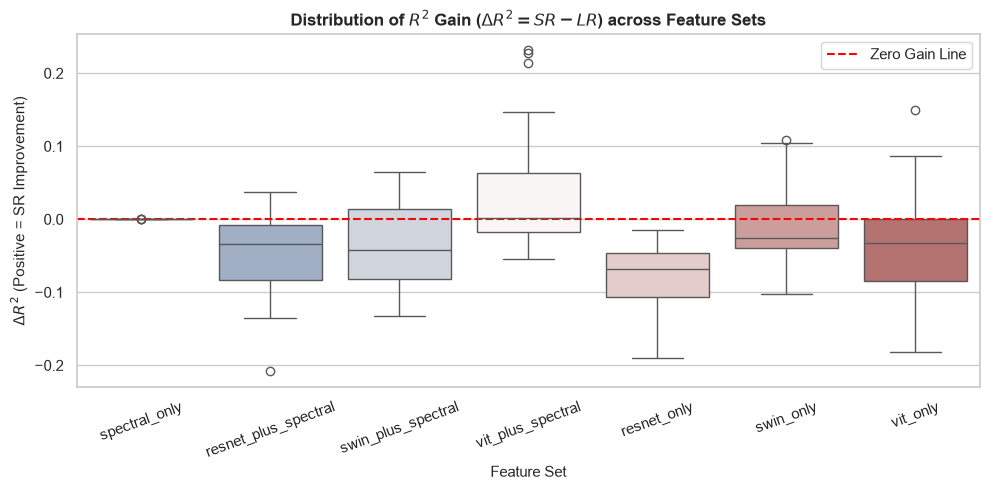

In [24]:
# ==========================================
# 3. DELTA ANALYSIS: GAINS FROM SUPER RESOLUTION (SR - LR)
# ==========================================
# Merge LR and SR summary statistics on matching configurations
merge_keys = ["feature_set", "selection_label", "regressor"]

df_merged_all = pd.merge(
    df_sum_lr,
    df_sum_sr,
    on=merge_keys,
    suffixes=("_LR", "_SR")
)

df_merged_all["delta_R2"] = df_merged_all["r2_mean_SR"] - df_merged_all["r2_mean_LR"]
df_merged_all["delta_RMSE"] = df_merged_all["rmse_mean_SR"] - df_merged_all["rmse_mean_LR"]
df_merged_all["delta_F1_macro"] = df_merged_all["severity_f1_macro_mean_SR"] - df_merged_all["severity_f1_macro_mean_LR"]

# Plot distribution of R2 gains per feature set
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_merged_all,
    x="feature_set",
    y="delta_R2",
    palette="vlag"
)
plt.axhline(0, color="red", linestyle="--", linewidth=1.5, label="Zero Gain Line")
plt.title("Distribution of $R^2$ Gain ($\Delta R^2 = SR - LR$) across Feature Sets", fontweight="bold")
plt.ylabel("$\Delta R^2$ (Positive = SR Improvement)")
plt.xlabel("Feature Set")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

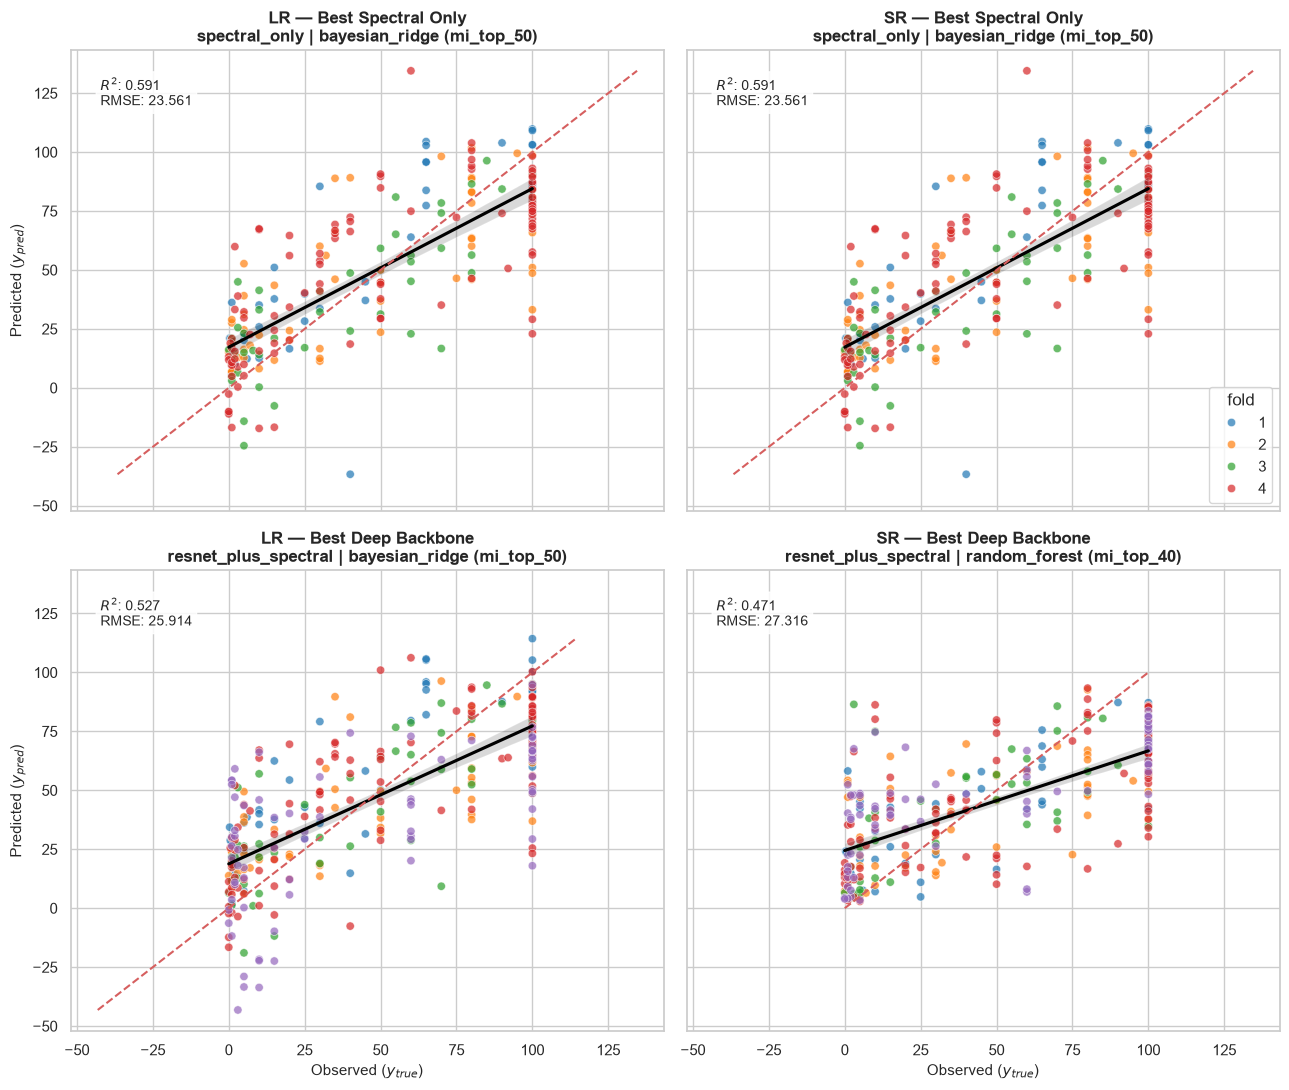

In [25]:
# ==========================================
# 4. 2x2 QUAD PLOT: BEST SPECTRAL VS BEST BACKBONE (LR vs SR)
# ==========================================
# Identify absolute best Spectral model and best Backbone model across both datasets
best_spectral_lr = df_sum_lr[df_sum_lr["feature_set"] == "spectral_only"].sort_values(by="r2_mean", ascending=False).iloc[0]
best_spectral_sr = df_sum_sr[df_sum_sr["feature_set"] == "spectral_only"].sort_values(by="r2_mean", ascending=False).iloc[0]

best_backbone_lr = df_sum_lr[df_sum_lr["feature_set"] != "spectral_only"].sort_values(by="r2_mean", ascending=False).iloc[0]
best_backbone_sr = df_sum_sr[df_sum_sr["feature_set"] != "spectral_only"].sort_values(by="r2_mean", ascending=False).iloc[0]

panel_configs = [
    ("LR — Best Spectral Only", df_pred_lr, best_spectral_lr),
    ("SR — Best Spectral Only", df_pred_sr, best_spectral_sr),
    ("LR — Best Deep Backbone", df_pred_lr, best_backbone_lr),
    ("SR — Best Deep Backbone", df_pred_sr, best_backbone_sr)
]

fig, axes = plt.subplots(2, 2, figsize=(13, 11), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (title_str, pred_df, config) in enumerate(panel_configs):
    ax = axes[idx]
    
    f_set = config["feature_set"]
    s_label = config["selection_label"]
    reg = config["regressor"]
    r2_val = config["r2_mean"]
    rmse_val = config["rmse_mean"]
    
    sub_preds = pred_df[
        (pred_df["feature_set"] == f_set) &
        (pred_df["selection_label"] == s_label) &
        (pred_df["regressor"] == reg)
    ]
    
    if sub_preds.empty:
        ax.set_title(f"{title_str}\n(No Predictions)")
        continue

    # Scatter plot by fold
    sns.scatterplot(
        data=sub_preds,
        x="y_true",
        y="y_pred",
        hue="fold",
        palette="tab10",
        alpha=0.7,
        ax=ax,
        legend=(idx == 1)
    )
    
    # Fit line
    sns.regplot(data=sub_preds, x="y_true", y="y_pred", scatter=False, color="black", ax=ax)
    
    # 1:1 Reference Line
    min_v = min(sub_preds["y_true"].min(), sub_preds["y_pred"].min())
    max_v = max(sub_preds["y_true"].max(), sub_preds["y_pred"].max())
    ax.plot([min_v, max_v], [min_v, max_v], 'r--', lw=1.5)
    
    ax.set_title(f"{title_str}\n{f_set} | {reg} ({s_label})", fontweight="bold")
    ax.set_xlabel("Observed ($y_{true}$)")
    ax.set_ylabel("Predicted ($y_{pred}$)")
    
    ax.text(
        0.05, 0.88,
        f"$R^2$: {r2_val:.3f}\nRMSE: {rmse_val:.3f}",
        transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85)
    )

plt.tight_layout()
plt.show()

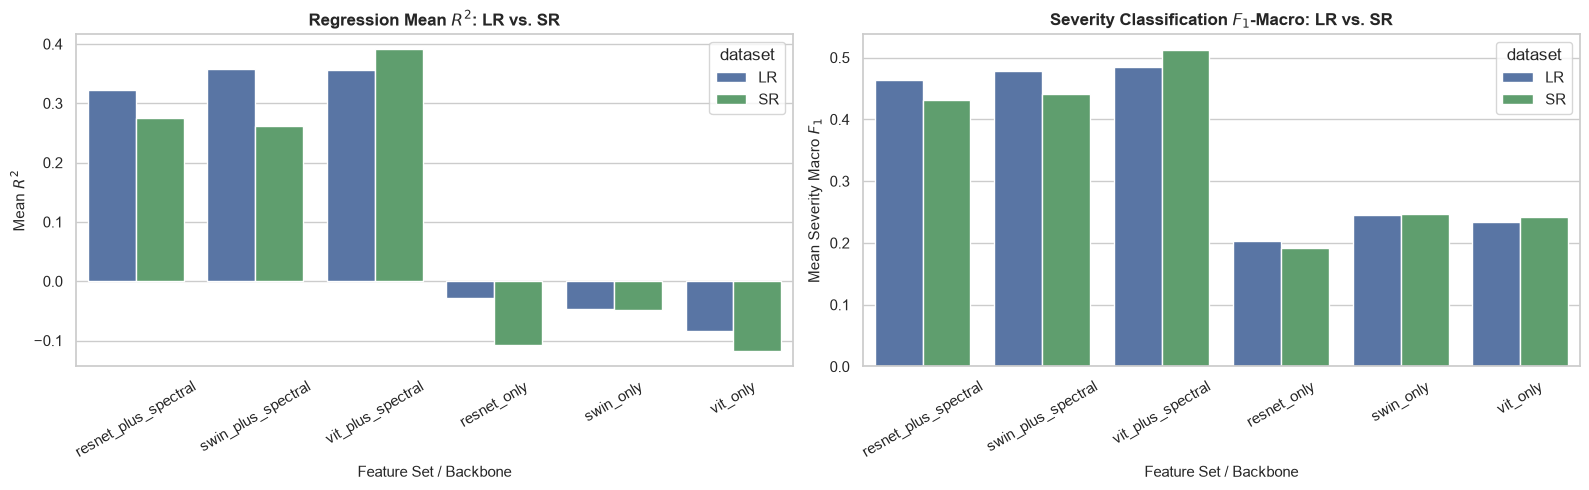

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: R2 Score Comparison (LR vs SR)
sns.barplot(
    data=df_sum,
    x="feature_set",
    y="r2_mean",
    hue="dataset",
    palette={"LR": "#4C72B0", "SR": "#55A868"},
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("Regression Mean $R^2$: LR vs. SR", fontweight="bold")
axes[0].set_ylabel("Mean $R^2$")
axes[0].set_xlabel("Feature Set / Backbone")
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: Severity Classification F1-Macro Comparison (LR vs SR)
sns.barplot(
    data=df_sum,
    x="feature_set",
    y="severity_f1_macro_mean",
    hue="dataset",
    palette={"LR": "#4C72B0", "SR": "#55A868"},
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Severity Classification $F_1$-Macro: LR vs. SR", fontweight="bold")
axes[1].set_ylabel("Mean Severity Macro $F_1$")
axes[1].set_xlabel("Feature Set / Backbone")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

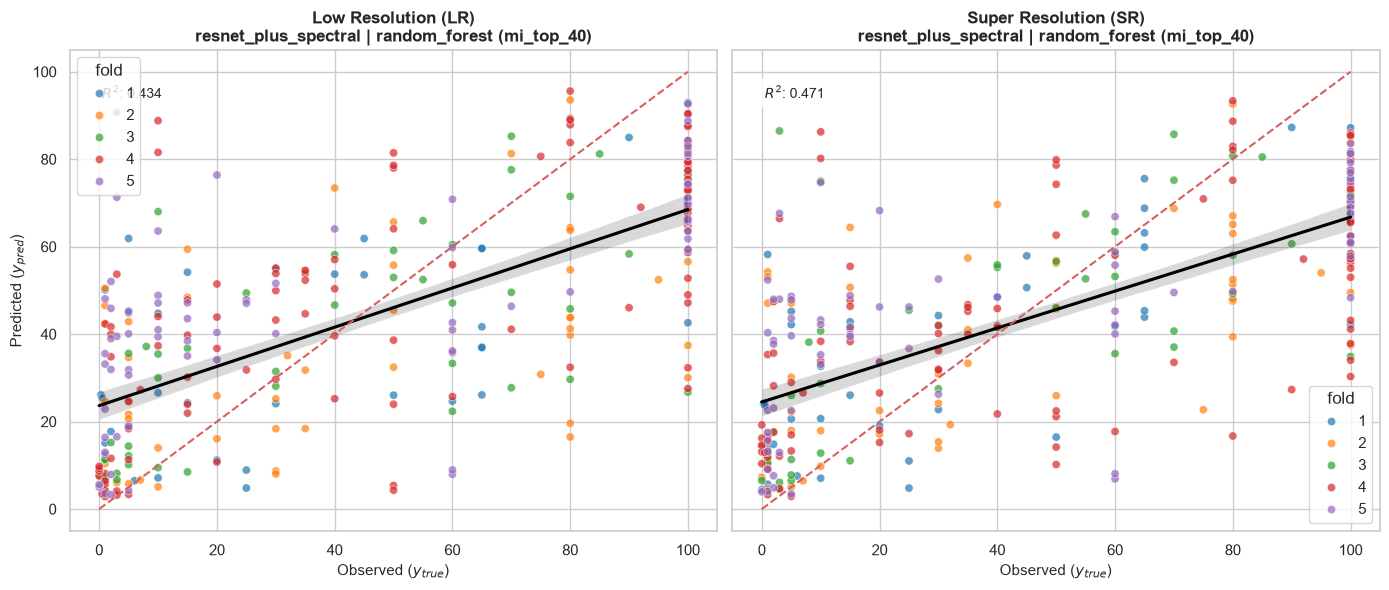

In [14]:
# Select absolute best model from SR dataset based on R2
best_sr_config = df_sum_sr[df_sum_sr["feature_set"] != "spectral_only"].sort_values(by="r2_mean", ascending=False).iloc[0]

f_set = best_sr_config["feature_set"]
s_label = best_sr_config["selection_label"]
reg = best_sr_config["regressor"]

# Filter predictions for LR and SR for this exact configuration
preds_lr_best = df_pred_lr[(df_pred_lr["feature_set"] == f_set) & (df_pred_lr["selection_label"] == s_label) & (df_pred_lr["regressor"] == reg)]
preds_sr_best = df_pred_sr[(df_pred_sr["feature_set"] == f_set) & (df_pred_sr["selection_label"] == s_label) & (df_pred_sr["regressor"] == reg)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, data_preds, stage_label in zip(axes, [preds_lr_best, preds_sr_best], ["Low Resolution (LR)", "Super Resolution (SR)"]):
    if data_preds.empty:
        ax.set_title(f"{stage_label}: Missing Predictions")
        continue
        
    sns.scatterplot(
        data=data_preds,
        x="y_true",
        y="y_pred",
        hue="fold",
        palette="tab10",
        alpha=0.7,
        ax=ax
    )
    
    # Fit regression line
    sns.regplot(data=data_preds, x="y_true", y="y_pred", scatter=False, color="black", ax=ax)
    
    # 1:1 reference line
    min_v = min(data_preds["y_true"].min(), data_preds["y_pred"].min())
    max_v = max(data_preds["y_true"].max(), data_preds["y_pred"].max())
    ax.plot([min_v, max_v], [min_v, max_v], 'r--', label="1:1 Reference")
    
    # Compute specific metrics for panel annotation
    r2 = data_preds.groupby("fold").apply(lambda g: 1 - np.sum((g["y_true"] - g["y_pred"])**2) / np.sum((g["y_true"] - g["y_true"].mean())**2)).mean()
    
    ax.set_title(f"{stage_label}\n{f_set} | {reg} ({s_label})", fontweight="bold")
    ax.set_xlabel("Observed ($y_{true}$)")
    ax.set_ylabel("Predicted ($y_{pred}$)")
    ax.text(0.05, 0.90, f"$R^2$: {r2:.3f}", transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

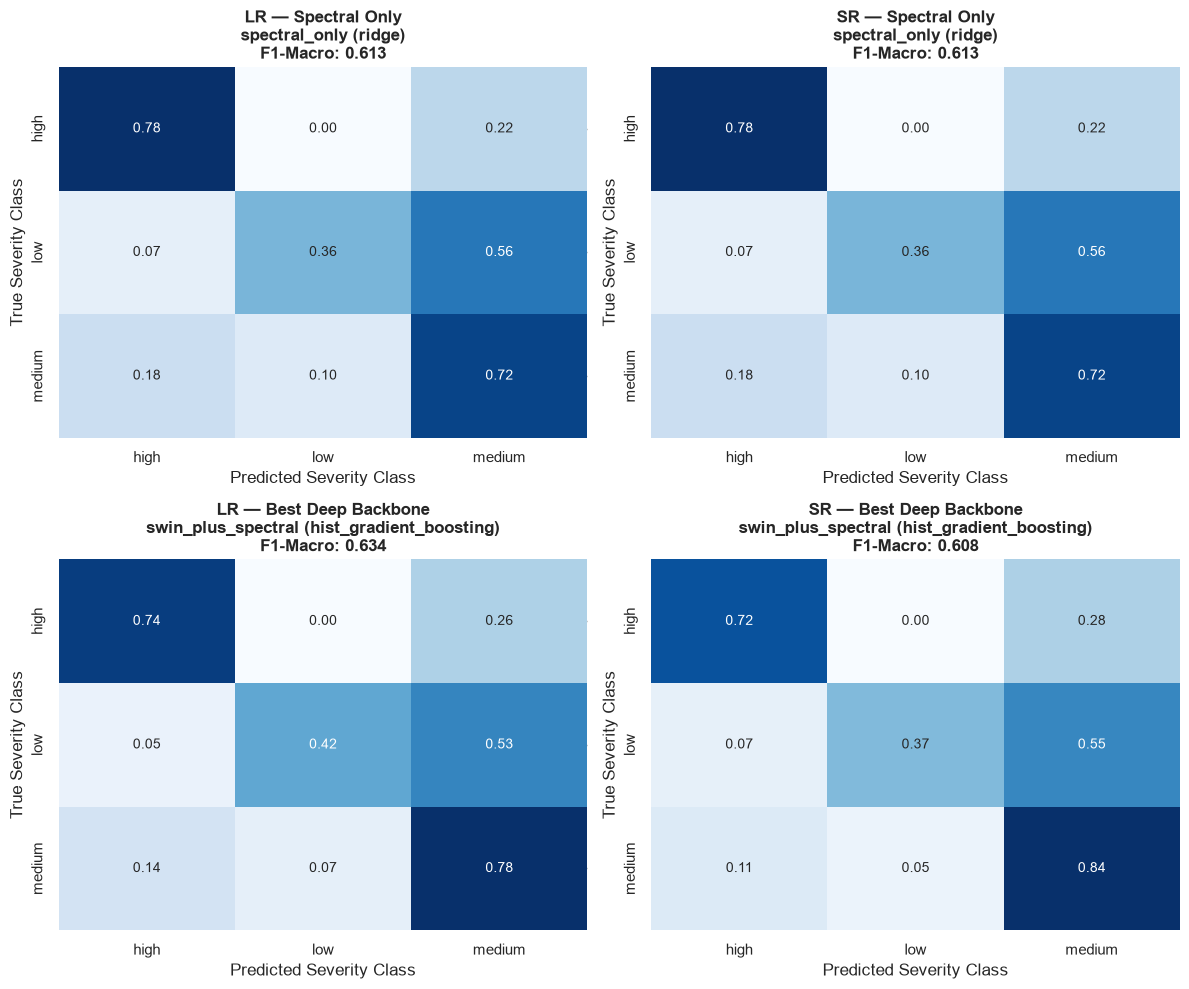

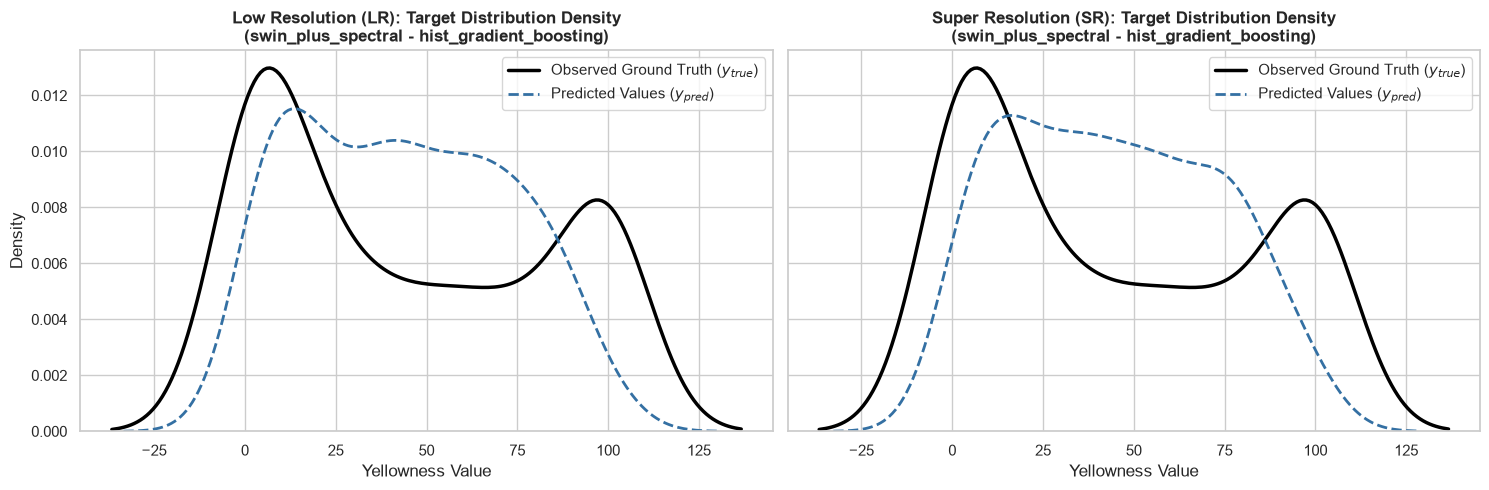

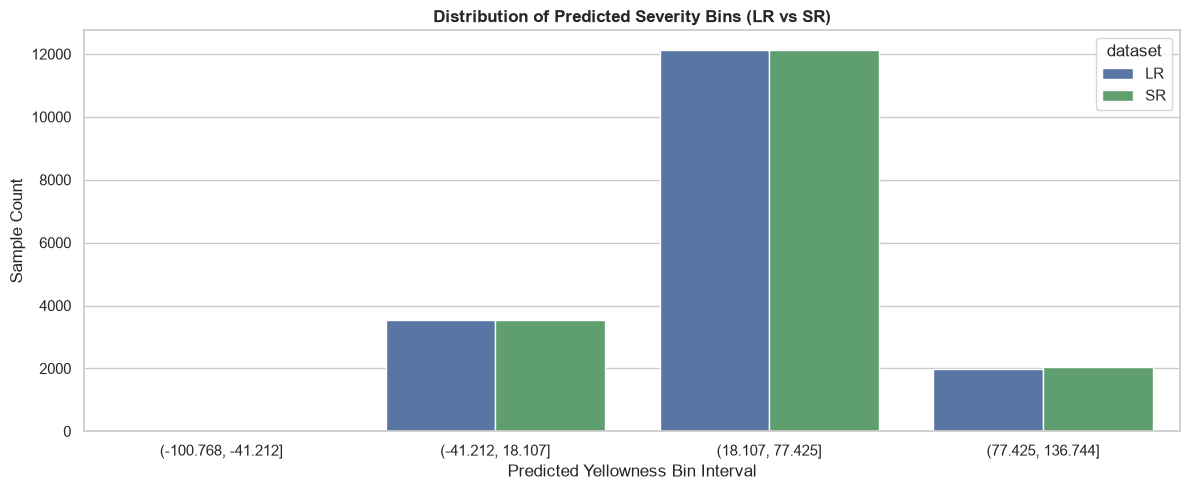

In [28]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
# Ensure global styles are set
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.size"] = 10

# ==========================================
# 1. CONFUSION MATRICES: LR VS SR (BEST MODELS)
# ==========================================
# Identify best classification configurations (by F1-Macro) for Spectral vs Backbone
best_lr_spec = df_sum_lr[df_sum_lr["feature_set"] == "spectral_only"].sort_values("severity_f1_macro_mean", ascending=False).iloc[0]
best_sr_spec = df_sum_sr[df_sum_sr["feature_set"] == "spectral_only"].sort_values("severity_f1_macro_mean", ascending=False).iloc[0]

best_lr_back = df_sum_lr[df_sum_lr["feature_set"] != "spectral_only"].sort_values("severity_f1_macro_mean", ascending=False).iloc[0]
best_sr_back = df_sum_sr[df_sum_sr["feature_set"] != "spectral_only"].sort_values("severity_f1_macro_mean", ascending=False).iloc[0]

configs = [
    ("LR — Spectral Only", df_pred_lr, best_lr_spec),
    ("SR — Spectral Only", df_pred_sr, best_sr_spec),
    ("LR — Best Deep Backbone", df_pred_lr, best_lr_back),
    ("SR — Best Deep Backbone", df_pred_sr, best_sr_back)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (title, pred_df, cfg) in enumerate(configs):
    ax = axes[idx]
    
    sub_preds = pred_df[
        (pred_df["feature_set"] == cfg["feature_set"]) &
        (pred_df["selection_label"] == cfg["selection_label"]) &
        (pred_df["regressor"] == cfg["regressor"])
    ].copy()
    
    # Extract true and predicted severity labels
    # If severity columns exist directly:
    if "severity_true" in sub_preds.columns and "severity_pred" in sub_preds.columns:
        y_true_class = sub_preds["severity_true"]
        y_pred_class = sub_preds["severity_pred"]
    else:
        # Fallback: Bin y_true and y_pred if classification metrics were calculated post-hoc
        # Adjust bins to match your exact severity scale boundaries
        bins = [-np.inf, 1.0, 2.0, 3.0, np.inf]
        labels = [0, 1, 2, 3]
        y_true_class = pd.cut(sub_preds["y_true"], bins=bins, labels=labels)
        y_pred_class = pd.cut(sub_preds["y_pred"], bins=bins, labels=labels)

    labels_sorted = sorted(y_true_class.unique())
    cm = confusion_matrix(y_true_class, y_pred_class, labels=labels_sorted, normalize='true')
    
    sns.heatmap(
        cm, 
        annot=True, 
        fmt=".2f", 
        cmap="Blues", 
        cbar=False,
        xticklabels=labels_sorted,
        yticklabels=labels_sorted,
        ax=ax
    )
    
    f1_val = cfg["severity_f1_macro_mean"]
    ax.set_title(f"{title}\n{cfg['feature_set']} ({cfg['regressor']})\nF1-Macro: {f1_val:.3f}", fontweight="bold")
    ax.set_xlabel("Predicted Severity Class")
    ax.set_ylabel("True Severity Class")

plt.tight_layout()
plt.show()

# ==========================================
# 2. TARGET CLUSTERING DIAGNOSTIC: OBSERVED VS DISCRETE PREDICTION DENSITY
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, dataset_label, pred_df, cfg_backbone in zip(
    axes, 
    ["Low Resolution (LR)", "Super Resolution (SR)"], 
    [df_pred_lr, df_pred_sr],
    [best_lr_back, best_sr_back]
):
    sub = pred_df[
        (pred_df["feature_set"] == cfg_backbone["feature_set"]) &
        (pred_df["selection_label"] == cfg_backbone["selection_label"]) &
        (pred_df["regressor"] == cfg_backbone["regressor"])
    ]
    
    sns.kdeplot(sub["y_true"], label="Observed Ground Truth ($y_{true}$)", color="black", linewidth=2.5, ax=ax)
    sns.kdeplot(sub["y_pred"], label="Predicted Values ($y_{pred}$)", color="#3470a3", linestyle="--", linewidth=2, ax=ax)
    
    ax.set_title(f"{dataset_label}: Target Distribution Density\n({cfg_backbone['feature_set']} - {cfg_backbone['regressor']})", fontweight="bold")
    ax.set_xlabel("Yellowness Value")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 3. CLASS PREDICTION BALANCE COMPARISON
# ==========================================
df_pred_combined["class_bin"] = pd.cut(df_pred_combined["y_pred"], bins=4)

plt.figure(figsize=(12, 5))
sns.countplot(
    data=df_pred_combined[df_pred_combined["feature_set"].isin(["spectral_only", best_sr_back["feature_set"]])],
    x="class_bin",
    hue="dataset",
    palette={"LR": "#4C72B0", "SR": "#55A868"}
)
plt.title("Distribution of Predicted Severity Bins (LR vs SR)", fontweight="bold")
plt.xlabel("Predicted Yellowness Bin Interval")
plt.ylabel("Sample Count")
plt.tight_layout()
plt.show()